## Ash Kuinkel ~ cosc102 assignment 2 (Please run all cells in sequential order, or click "run all" at the top for a smoother experience)

### Brief Overview (Description of the program):
This program is crafted in a single section to accomplish our task as listed below;

Firstly, what is classification? Classification is a supervised machine learning task which relies on labelled data (i.e. input data labelled with what class they belong to), learns from this & uses this information learnt to be able to predict which new unseen items belong to which class. Our given task, follows a textbook application of modelling a classification workflow.

**Wine-Cultivar Classification** - We are required to apply a classifier algorithm of our liking to create a classifier which is able to classify the cultivar (specific type of grape grown in the vineyard) of wines from vineyards grown within the same region in Italy based upon 2 of the highest performing features ( selected using cross validation) out of the 13 available. A general gist/speculation on why only 2 features, will be provided further down below. The general set of steps that should be followed have been provided in the task description; loading dataset/partitioning, feature selection using cross validation, creating confusion matrix of classifiers performance on test set as well as calculating recall/precision/f1 scores, plotting & calculating ROC/AUC for each of the classes, demonstrating decision boundaries learnt by classifier w/ testing data points included in the form of a visual, i.e. scatter plot.


*I want to present my findings/what I have learnt for each of the steps (as this is how I worked through the assignment, step by step). So lets begin with what I first did, downloading and taking a look at the dataset.*

There were 2 things that stood out to me; a file named **wine.data** (which was of less importance) containing the 178 entries of all the different wines within the dataset & **wine.names** (of more importance) which specified what the dataset is actually containing. So from the wine.names I found that this dataset was derived from a chemical analysis, of wines in same region of Italy containing 3 different cultivars, which determined quantities of 13 chemical elements/parts found within each of the 3 types of wines. Also it lists that the author initially had approx. 30 variables instead of 13, but it appears that the author has lost the initial dataset. Anyways, the 13 features are listed here:

 	1) Alcohol
 	2) Malic acid
 	3) Ash
	4) Alcalinity of ash  
 	5) Magnesium
	6) Total phenols
 	7) Flavanoids
 	8) Nonflavanoid phenols
 	9) Proanthocyanins
	10)Color intensity
 	11)Hue
 	12)OD280/OD315 of diluted wines
 	13)Proline     

& we also see the number of instances of each class, i.e. (how many of the 178 entries belong to either class 1, 2 & 3):

    class 1 59
	class 2 71
	class 3 48 

This raises a subtle thought/question for me... It seems as if there are a little bit more instances of class 2, than class 1 or 3, so **should we automatically assume that the classifier will have some inclination to predict class 2 more often than the others (especially as we get closer to decision boundaries)?** But on second thought, I realise that the imbalance between the classes is very minimal. Either way, this is something to keep an eye on as we proceed through the later steps.

### <u>Step 1 (Load dataset and partition dataset in the train/test sets):</u>

Lets first begin by importing the required libraries/modules that we will need to make use of throughout the program. ```sklearn.datasets``` enables us to fetch our wine cultivar dataset, ```sklearn.linear_model``` features linear models, including the SGDClassifier which will be the classifier algorithm we use for this task, ```sklearn.model_selection``` allows us to import our train_test_split method which makes it easy to parition our dataset (crucial for step 1) & the cross_val_predict method allowing for our training set to be split in folds & trains model on these folds and tests on unseen fold (all within training set, test set is not touched until very end), ```sklearn.metrics``` allows us to import methods for later steps, i.e. calculating confusion matrix, f1/recall/precision scores + roc/auc, ```sklearn.preprocessing``` imports label_binarize allowing for our multi-class label list to transform into a matrix (on one vs rest) so e.g. the matrix would have a row like [ 1 0 0 ] which would mean this is of class 1, [ 0 1 0 ] which is of class 2 etc.., ```matplotlib.pyplot``` allowing us to craft our visualisations, ```sklearn.pipeline``` & ```sklearn.preprocessing``` which automates the process of standardisation of our train/test data for SGDClassifier **COME BACK TO THIS ONE & FIX THE DEFINITION I KNOW IT'S WRONG HERE FOR THE PIPELINE/STANDARDISATION** & finally ```numpy``` for its multi-dimensional arrays & numerical operations.

In [36]:
from sklearn.datasets import load_wine
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split,cross_val_predict
from sklearn.metrics import confusion_matrix,f1_score,recall_score,precision_score,roc_curve,auc,ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

Now we must first load the wine dataset from scikit learn:

In [37]:
data = load_wine()

This is the other peice of the puzzle for step 1 & requires us to parition the data into training and test sets. We use the method we imported above the ```train_test_split``` which ensures **GET A DEEPER UNDERSTANDING OF HOW THIS TRAIN TEST SPLIT IS ACTUALLY WORKING & THEN FINISH THIS OFF**

In [38]:
X, y = data["data"],data["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0) # note that our random state
# & ensures....

....

This is all we must do for our first step. We can now move onto the second step which requires a bit more thinking.

### <u>Step 2 (Selecting 2 higher performing features based on cross-validation):</u>

This is the step which requires us to select the 2 highest performing features based upon cross validation carried out on the training set. 

I want to diverge from the main discussion here & first walk through my initial thought/workflow regarding this step before discussing my final implementation. So, at first this was my exact thought process (it is indeed a comment I wrote during the first draft of my task): 

```
# for choosing the features i.e. feature selection im thinking about either calculating like the scores for the model then 
# simply using like a for loop to compare and pull out two of the highest ones? Maybe that's what the task wants when it
# says Select the 2 most higher-performing features based upon cross-validation carried out on the training dataset.
# or im thinking maybe using RFE would be suitable which i picked up from this article:
# https://medium.com/@shradhdha.bhalodia/cross-validation-feature-selection-and-model-evaluation-with-scikit-learn-edc0e414c74e
# Even more interesting I came to this:
# https://www.geeksforgeeks.org/machine-learning/recursive-feature-elimination-with-cross-validation-in-scikit-learn/
```

I was hoping that there would maybe be a convinient method implementation already provided in SciKit learn to help us select the best performing features, rather than me having to write the for loops and compute e.g. the f1 scores to determine best features. So I came across this article on medium & reading this section, i.e.:

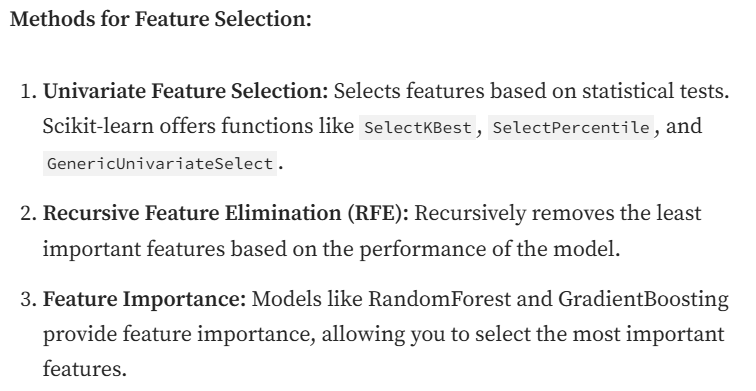

It seemed as if RFE (Recursive Feature Enlimination) kind of matched the behaviour we wanted our classifier program to follow & sure enough one browser search on *'RFE Scikit'* led me to exactly what I thought I needed. But reading the scikit documentation for RFE, in particular, the *'see also'* section, I saw something I thought was even better cut out for step 2 and did it exactly as outlined in our task description:

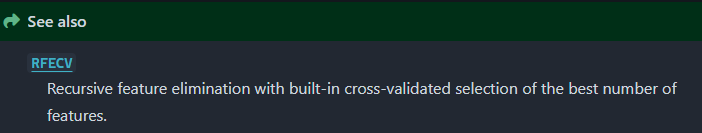

However, the *RFECV* posed a problem. We had a *min_features_to_select* param, but nothing to restrict the amount of features we want. I did indeed try setting *min_features_to_select* to 2 but it gave me 3 best features, so I thought we couldn't really make use of this & went back to looking at the *RFE*. I attempted to combine *RFE* with cross validation in such manner:

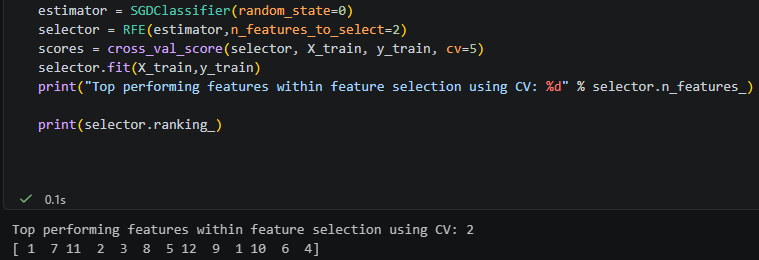

But I approached this in the other way I first thought of, i.e with the for loops (just to verify that I would get the same 2 features) and got back a completely different answer for the 2 best features. So I immediately knew that something was most likely wrong with the way I used *RFE* & the cv. Only by looking deeper into it, that I realised *RFE* is probably not the best for the task we want to acheive. 

Scikit learn's documentation page for *RFE* Specifically says ```Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), the goal of RFE....importance of each feature is obtained either through any specific attribute or callable```, so my interpretation of this is that *RFE* takes the 13 features which have had weights learnt by the SGDClassifier (the external estimator in this case), and because we're using SGDClassifier, a linear classifier, it uses (by default) the attribute ```coef_``` which would represent weight/coefficient matrix (according to https://scikit-learn.org/stable/glossary.html#term-coef_) for the features. So our RFE will use these weights/coefficients & just rank them & remove the worst one (so now 12 features remaining). It then trains the model again on the 12 features, learns some new weights/coefficeints removes the worst one etc. until we're left with 2 only.

But this was looking at features individually. I then realised, RFE/RFECV is not good enough because we want 2 most higher performing features, so we will literally have to pick out all possible combinations of 2 features, 13C2 = 13!/2!*(11)! so 78 total combinations and pick the one that scores the highest f1 scores etc....

So i ended up sticking with the for loop approach I initially thought of:

In [ ]:
best_feature1 = 0
best_feature2 = 0
ttl_feature_amount = 13

def select_2_high_performing_features_based__on_cv(ttl_feature_amount : int) -> list[int]:
    '''
      Outputs the 2 highest performing features based on a total number of (ttl_feature_amount) features/cross validation & uses f1 scores as the performance metric.
    
      Args:
        ttl_feature_amount (int) : the total amount of features within the dataset.
    
      Returns:
        list[int] : [best_feature1,best_feature2] - the highest combination of features, with performance measured based on the f1 scores.
    '''
    best_mean_f1 = 0; # here we choose f1 as our performance metric, it serves as a good metric to use
    # considering it covers both accuracy & recall. 

    # The nested loop structure we have is going through all 169 possible pairings, but we intentionally skip the ones where feature 1 & feature 2 are the same so we have less than 169 iterations.
    # Also, the loops will consider like (2,3) & (3,2) different & will re-train the model on them, but given our input size is only like 13 features, and even up to some hundred features, I doubt that
    # it will have any significant effect on the speed/efficiency of our program. Hence, I have decided to leave this for now.
    for feature1 in range(ttl_feature_amount): 
        for feature2 in range(ttl_feature_amount):
            
            # we don't want to consider the combination where the 2 features are equal, so we 
            # can simply skip the iteration where they are indeed equal using the continue:
            if feature1 == feature2:
                continue
            
            curr_features_list = [feature1,feature2] # grab the two current features we're iterating over as we will use this to train the SGDClassifier model & compare it to other combinations of features...
            
            # With the Pipeline we are allowing a list of transformers which will help in preprocessing our data,
            # as listed here: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline
            # only within the pipeline do we define our standard scaler & our SGDClassifier.
            # The StandardScaler() ensures that we remove the mean & scale all features to have a variance of 1 (and hence std deviation of 1 as well because sqrt(1) = 1).
            # This is particularly important as our features may not exactly follow a symmetric/normal distribution & hence this could affect the best features output we are given by this function.
            # (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
            # There is more on this in the notebook md section just below this cell.
            sgd_clf = Pipeline([("scaler",StandardScaler()),("sgd",SGDClassifier(random_state=0))]) 
            
            sgd_clf.fit(X_train[:,curr_features_list],y_train) # calling the .fit() method to train our SGDClassifier on all rows but only of the 2 current features we are iterating over. 
            
            # will run 5 fold cv using our SGDClassifier & the 2 features to predict targets & returns cross validated estimates for every input data point
            # as according to (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html)
            y_pred = cross_val_predict(sgd_clf,X_train[:,curr_features_list],y_train,cv=5) 
            
            curr_mean_f1 = np.mean(f1_score(y_train,y_pred,average=None)) # calculates the f1 score for all of our classes based on the model we just trained using the two features, then takes the mean and 
            # compares it to how the other features do. The average None ensures that we are able to handle our multi-class data as only then does scikit return one score for each of the classes,
            # if we didn't have average=None param we'd get an error here, as seen in the cell below.
            
            if curr_mean_f1 > best_mean_f1: # in other words, if the current pair of features is the best we've seen so far update our features/best mean f1 to the current pair/f1 score
                best_mean_f1 = curr_mean_f1
                best_feature1 = feature1
                best_feature2 = feature2

    print("Best feature 1: %d " % (best_feature1+1) + "which is also labelled: %s" % data.feature_names[best_feature1]) # I print out best_feature1 + 1 because python starts lists at 0, but dataset i.e. (wine.names file) starts it at 1, so to be a bit more accurate.
    print("Best feature 2: %d " % (best_feature2+1) + "which is also labelled: %s" % data.feature_names[best_feature2]) # Same story for this one too.
    print(f"Best mean F1: {best_mean_f1}")
    
    return [best_feature1,best_feature2]
        

As the task description mentions; *built-in functions for creating train/test split & the CV select data points randomly...running workflow many times may result in different results.* So this is something we have to keep in consideration, but the program has indeed been constructed to select the 2 highest performing features.

The Pipeline is used so we can automate the preprocessing with StandardScaler, we could do it manually as well but then there is a greater chance of error.

I also first tried the current mean calculation this without the ```average=None parameter```, and it seems that if we do not pass in ```average=None``` then scikit just defaults it to ```average='binary'``` and this is a problem for us since we are training a multi-class classifier not just a binary classifier, so it will not be able to perform the mean calculation, hence why this parameter is important.

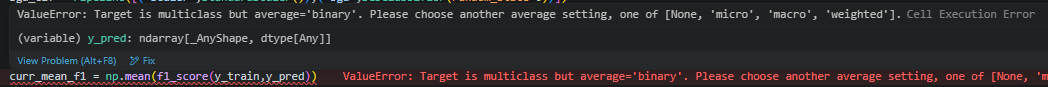

I think this step, i.e. step 2 required the most thought and time compared to the other steps within the task, but it is also one where I did learn a lot about feature selection in particular as well as the differences when handling a dataset with just 2 classes vs more than 2 classes.

So we have now fulfilled the requirements of the second step. Lets move onto the third:

### <u>Step 3 (Confusion matrix on classifier test set performance + Recall/Precision/F1 scores for classes):</u>

So for step 3, we must now first train the classifier on the 2 higher performing features based on our cv we found from our function above.

The implementation of this is quite simple, we are required to grab the two best features, train our model on them & see how they perform against the unseen test dataset. I think it is also important to note here once again that the test data must remain untouched until the very end. If we expose our model to the intended test data during training, then it will be tested on things it has already seen before, which does no good for calculating the accuracy,precision etc. of our model.

Best feature 1: 12 which is also labelled: od280/od315_of_diluted_wines
Best feature 2: 13 which is also labelled: proline
Best mean F1: 0.9028337562820322
Confusion Matrix:
 [[16  0  0]
 [ 1 18  2]
 [ 1  0  7]]


Text(0.5, 1.0, 'Confusion Matrix Visualisation on classifier performance on wine cultivar test set')

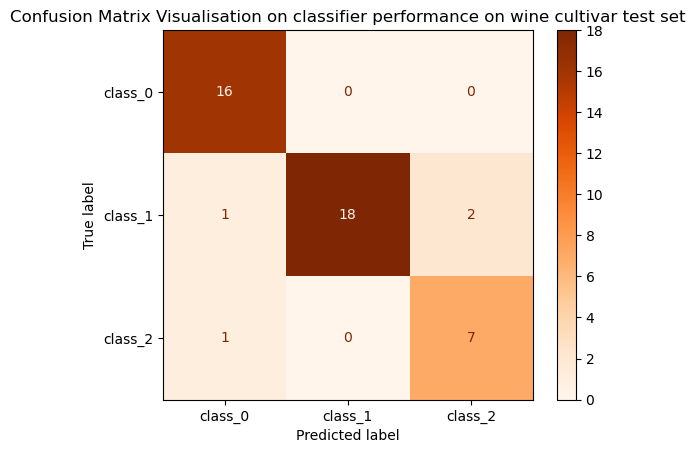

In [40]:
best_features_list = select_2_high_performing_features_based__on_cv(ttl_feature_amount) # storing the result of our function inside the var to use for later steps.

# once again, we use the pipeline like before here to standardise our training/test data for the SGDClassifier.
sgd_clf = Pipeline([("scaler",StandardScaler()),("sgd",SGDClassifier(random_state=0))])
sgd_clf.fit(X_train[:,best_features_list],y_train) # training model on the two higher performing features

y_pred = sgd_clf.predict(X_test[:,best_features_list]) # using the two features only from our test dataset, here is where our classifier is predicting what class every entry should belong to based on it's training data... truly, a very cool line ;) 

conf_matrix = confusion_matrix(y_test,y_pred) # the confusion_matrix() method lets us conviniently calculate our confusion matrix to evaluate the accuracy of our classifier... 
# (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)  

print(f"Confusion Matrix:\n {conf_matrix}") # printing out the conf matrix to CLI

# These next sequence of steps are all taken to help us visualise the confusion matrix:
fig,ax = plt.subplots()
ConfusionMatrixDisplay.from_estimator(sgd_clf,X_test[:,best_features_list],y_test,display_labels=data.target_names,cmap=plt.cm.Oranges,ax=ax)
ax.set_title("Confusion Matrix Visualisation on classifier performance on wine cultivar test set")


So we first see that our function is printing out the 2 best identified features (because of the print statements in the function). The f1 score is used as a metric to determine how well our model did, since it is a harmonic mean of the precision and recall, the best mean f1 of our model was ~0.9 which is very good. So our function has gotten this best mean f1 score with the features ```od280/od315_of_diluted_wines``` & ```proline```. 

From the confusion matrix, we see that the model correctly identified all the class 0 elements. For class 1, it classified 18 correctly, however it classified 1 as class 0 and 2 as class 2. Finally, for class 2, it classified 7 correctly as class 2, but it classified 1 as class 0. Using this confusion matrix we can manually calculate the precision, recall, f1 scores, but scikit learn already has some methods we can use for this job.

In [41]:
recall = recall_score(y_test,y_pred,average=None)
precision = precision_score(y_test,y_pred,average=None)
f1 = f1_score(y_test,y_pred,average=None)

print(f"Recall Score : {recall}" )
print(f"Precision Score : {precision}" )  
print(f"F1 score: {f1}" ) 

Recall Score : [1.         0.85714286 0.875     ]
Precision Score : [0.88888889 1.         0.77777778]
F1 score: [0.94117647 0.92307692 0.82352941]


So how can we interpret these results now? Well, we know, in simple words recall is a measure of how many intended targets did our model find? To be more precise it is a measure of ( true positives/ (true positives) + (false negatives)). Recall is very important for cases where we want to make sure we are not missing out on any targets and having a false negative will have more consequences as compared to false positives. On the other hand, precision is a measure of all the positives model was able to predict, how many were actually positive. Once again, to be more precise it is a measure of (true positives/(true positives + false positives)) and precision is very important for cases where we want to avoid having any false positives i.e. when we want to make sure what's in our class 1 actually belongs to class 1. We do also know the trade-off between recall & precision, i.e. as recall increases, precision decreases & vice versa, this inverse relationship is reflected through our confusion matrix, recall/precision scores, e.g. when recall score is 1 for class 0, the precision score is 0.89 (2.d.p) etc. We see our f1 scores for class 0 & class 1 are excellent (90+), and our f1 score for class 2 is good (80+).

I also want to discuss an important point here. While the marking rubric does say ```Have you generated general-purpose/reusable functions?``` I have intentionally not generated a function for this step. I argue that there is no need for function here. We could indeed create one, but who knows, maybe next time you want to use the KNN algorithm, or maybe you want to change the colour of your confusion matrix, either way the core logic in this step only spans approx. ~4 lines (that is definetly not to say the amount of lines you have in your code dictates if a function is necessary all the time, it does not) and is not something that will benefit much from having a reusable function. In fact, i argue that attempting to create a function here will only strip away the simplicity/flexibility of the program.

### <u>Step 4 (ROC Values for classes & Auc calculations):</u>

In [42]:
y_scores = sgd_clf.decision_function(X_test[:,best_features_list])

y_test_bin = label_binarize(y_test,classes=[0,1,2])
false_positive_rate = dict()
true_positive_rate = dict()
roc_auc = dict()

for i in range(3):
    false_positive_rate[i],true_positive_rate[i],_ = roc_curve(y_test_bin[:,i],y_scores[:,i])
    roc_auc[i] = auc(false_positive_rate[i],true_positive_rate[i])
# & Also make sure we plot these roc curves for each of the classes along with the AUC..
# & how we should interpret the results
print(roc_auc)

{0: 0.997844827586207, 1: 0.9781746031746031, 2: 0.9527027027027026}


### <u>Step 5 (Visualisation including decision boundary):</u>

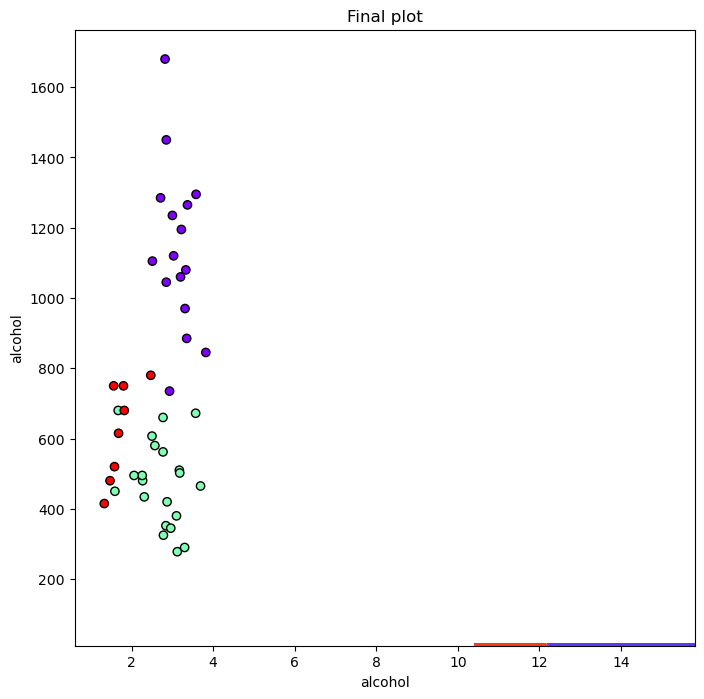

In [43]:
X_train_selected = X_train[:,best_features_list]
X_test_selected = X_test[:,best_features_list]

# creating the mesh to plot in:
x_min, x_max = X_test[:,best_feature1].min() - 1, X_test[:,best_feature1].max() + 1
y_min, y_max = X_test[:,best_feature2].min() - 1, X_test[:,best_feature2].max() + 1

xx,yy = np.meshgrid(np.arange(x_min,x_max,0.02),np.arange(y_min,y_max,0.2))

grid_predictions = sgd_clf.predict(np.c_[xx.ravel(),yy.ravel()])

# putting result into colour shape:
grid_predictions = grid_predictions.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8,8))

ax.contourf(xx,yy,grid_predictions,cmap="rainbow")

ax.scatter(X_test_selected[:,0],X_test_selected[:,1],c=y_test,cmap="rainbow",edgecolor="black")

plt.xlabel(data.feature_names[best_feature1])
plt.ylabel(data.feature_names[best_feature2])
plt.title("Final plot")

plt.show()